## STAT 306 Project: Vancouver Land Value Associated with Prior Year Values and Age

In [55]:
library(tidyverse)
library(broom)
library(ggplot2)
library(car)
library(GGally)
library(broom)

--------------------------
#### Data cleaning

In [94]:
unique(property_sample$ZONING_CLASSIFICATION)

[1] "Residential Inclusive"     "One-Family Dwelling"      
 [3] "Comprehensive Development" "Industrial"               
 [5] "Commercial"                "Multiple Dwelling"        
 [7] "Residential"               "Two-Family Dwelling"      
 [9] "Historical Area"           "Other"                    
[11] ""                          "Residential Rental"       
[13] "Limited Agriculture"

In [95]:
set.seed(306)

property_sample <- read.csv(file = "data\\sample_data.csv")

property_cleaned <- property_sample |>  
                    select(
                        LEGAL_TYPE, 
                        ZONING_CLASSIFICATION, 
                        CURRENT_LAND_VALUE,
                        CURRENT_IMPROVEMENT_VALUE, 
                        PREVIOUS_LAND_VALUE, 
                        PREVIOUS_IMPROVEMENT_VALUE, 
                        YEAR_BUILT,
                        ) |>
                    na.omit() |>
                    filter(
                        CURRENT_LAND_VALUE > 1 &
                        CURRENT_IMPROVEMENT_VALUE > 1 & 
                        PREVIOUS_IMPROVEMENT_VALUE > 1 &
                        PREVIOUS_LAND_VALUE > 1 &
                        LEGAL_TYPE != "OTHER"
                        ) |>
                    mutate(
                        LEGAL_TYPE = as.factor(LEGAL_TYPE),
                        ZONING_CLASSIFICATION = as.factor(ZONING_CLASSIFICATION),
                        ZONING_CLASSIFICATION = case_when(
                        ZONING_CLASSIFICATION %in% c(
                            "Residential",
                            "Residential Inclusive",
                            "Residential Rental",
                            "One-Family Dwelling",
                            "Two-Family Dwelling",
                            "Multiple Dwelling"
                        ) ~ "Residential",

                        ZONING_CLASSIFICATION %in% c(
                            "Commercial",
                            "Comprehensive Development"
                        ) ~ "Commercial/Mixed",

                        ZONING_CLASSIFICATION == "Industrial" ~ "Industrial",

                        ZONING_CLASSIFICATION %in% c(
                            "Historical Area",
                            "Other",
                            "Limited Agriculture",
                            ""
                        ) ~ "Special/Other",

                        TRUE ~ as.character(ZONING_CLASSIFICATION)
                        
                        ),
                        ZONING_CLASSIFICATION = as.factor(ZONING_CLASSIFICATION)
                    )



# Check how many rows were dropped
nrow(property_sample) - nrow(property_cleaned) 
nrow(property_sample)
head(property_cleaned)

[1] 105

[1] 2000

,LEGAL_TYPE,ZONING_CLASSIFICATION,CURRENT_LAND_VALUE,CURRENT_IMPROVEMENT_VALUE,PREVIOUS_LAND_VALUE,PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT
,<fct>,<fct>,<dbl>,<int>,<dbl>,<int>,<int>
1,LAND,Residential,1947000,34600,1977000,37800,1961
2,LAND,Residential,1324000,281000,1530000,274000,1995
3,STRATA,Commercial/Mixed,336000,199000,315000,187000,1985
4,STRATA,Industrial,1898000,228000,1879000,225000,1990
5,STRATA,Commercial/Mixed,252000,16700,216000,17300,1975
6,LAND,Residential,2939000,147000,2708000,129000,1964


--------------------------
#### EDA

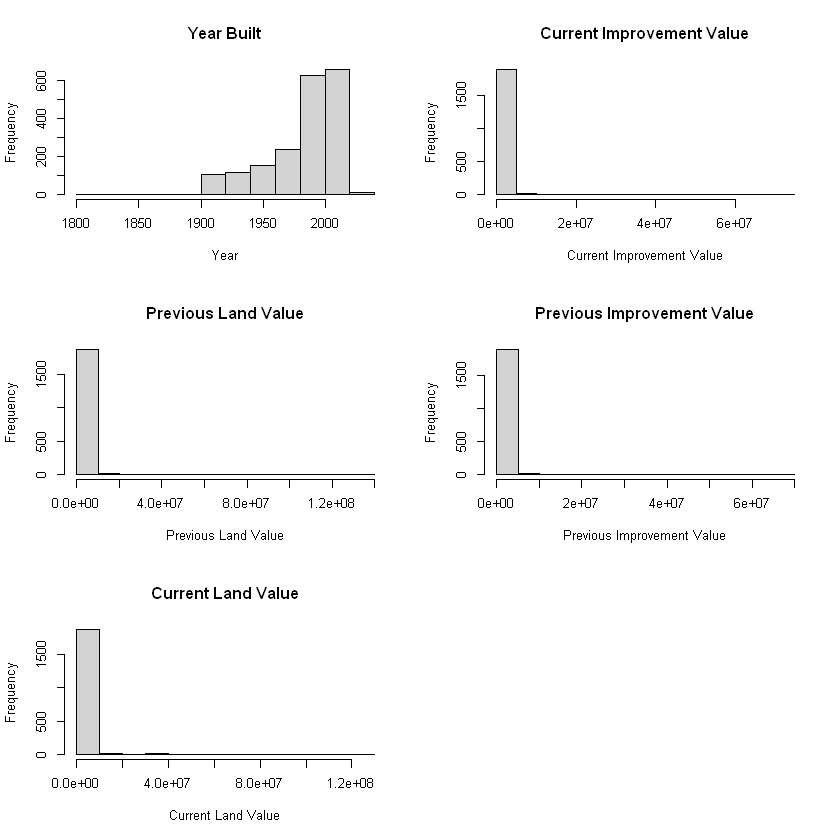

In [96]:
# Distribution Check
par(mfrow = c(3,2))
hist(property_cleaned$YEAR_BUILT,
     main = "Year Built",
     xlab = "Year")
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Current Improvement Value", xlab = "Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "Previous Land Value", xlab = "Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "Previous Improvement Value", xlab = "Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "Current Land Value", xlab = "Current Land Value")

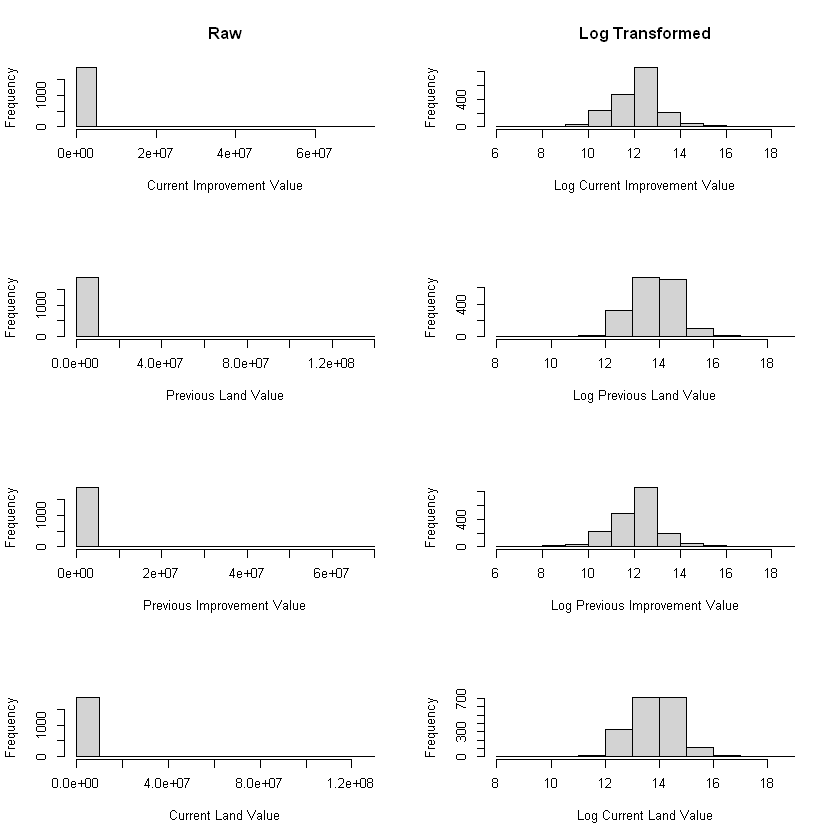

In [97]:
# Log-transformation Justification
par(mfrow = c(4,2))
hist(x = (property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Raw", xlab = "Current Improvement Value")
hist(x = log(property_cleaned$CURRENT_IMPROVEMENT_VALUE), main = "Log Transformed", xlab = "Log Current Improvement Value")
hist(x = (property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Previous Land Value")
hist(x = log(property_cleaned$PREVIOUS_LAND_VALUE), main = "", xlab = "Log Previous Land Value")
hist(x = (property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Previous Improvement Value")
hist(x = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE), main = "", xlab = "Log Previous Improvement Value")
hist(x = (property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Current Land Value")
hist(x = log(property_cleaned$CURRENT_LAND_VALUE), main = "", xlab = "Log Current Land Value")

In [98]:
# Class Imbalance Check
counts1 <- table(property_cleaned$LEGAL_TYPE)
counts1

round(100 * prop.table(table(property_cleaned$LEGAL_TYPE)), 2)

counts2 <- table(property_cleaned$ZONING_CLASSIFICATION)
counts2

round(100 * prop.table(table(property_cleaned$ZONING_CLASSIFICATION)), 2)


  LAND STRATA 
   753   1142 


  LAND STRATA 
 39.74  60.26 


Commercial/Mixed       Industrial      Residential    Special/Other 
             856               55              944               40 


Commercial/Mixed       Industrial      Residential    Special/Other 
           45.17             2.90            49.82             2.11 

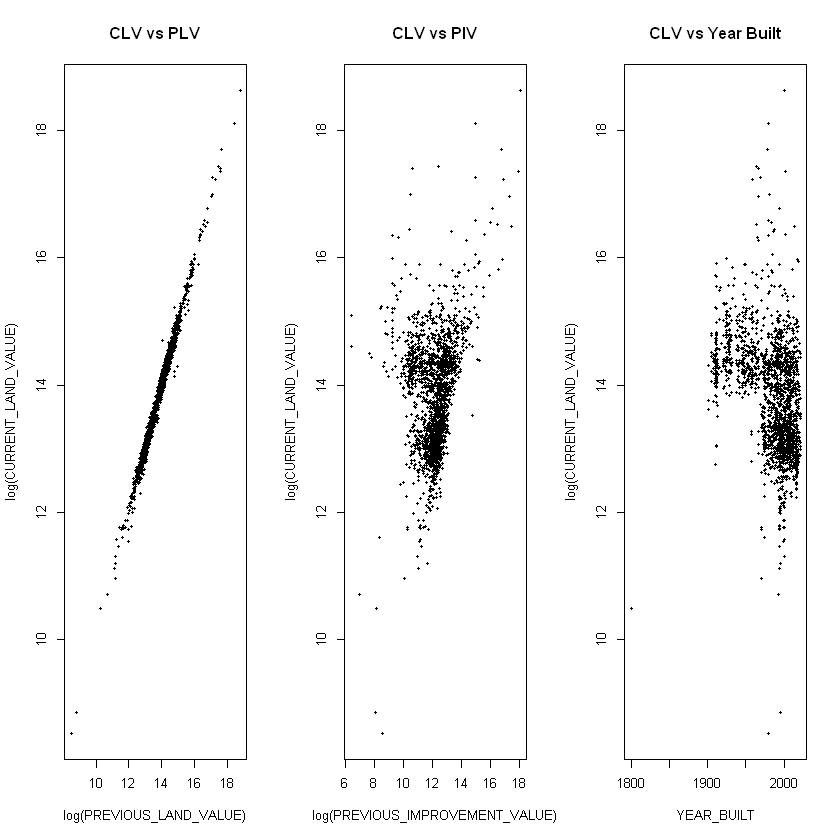

In [99]:
# Response vs Covariates
#png("scatterplots.png", width = 700, height = 400)

par(mfrow = c(1, 3))

plot(x = log(property_cleaned$PREVIOUS_LAND_VALUE),
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "log(PREVIOUS_LAND_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PLV")


plot(x = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE),
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "log(PREVIOUS_IMPROVEMENT_VALUE)",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs PIV")


plot(x = property_cleaned$YEAR_BUILT,
     y = log(property_cleaned$CURRENT_LAND_VALUE),
     pch = 16, cex = 0.5,
     xlab = "YEAR_BUILT",
     ylab = "log(CURRENT_LAND_VALUE)",
     main = "CLV vs Year Built")

#dev.off()

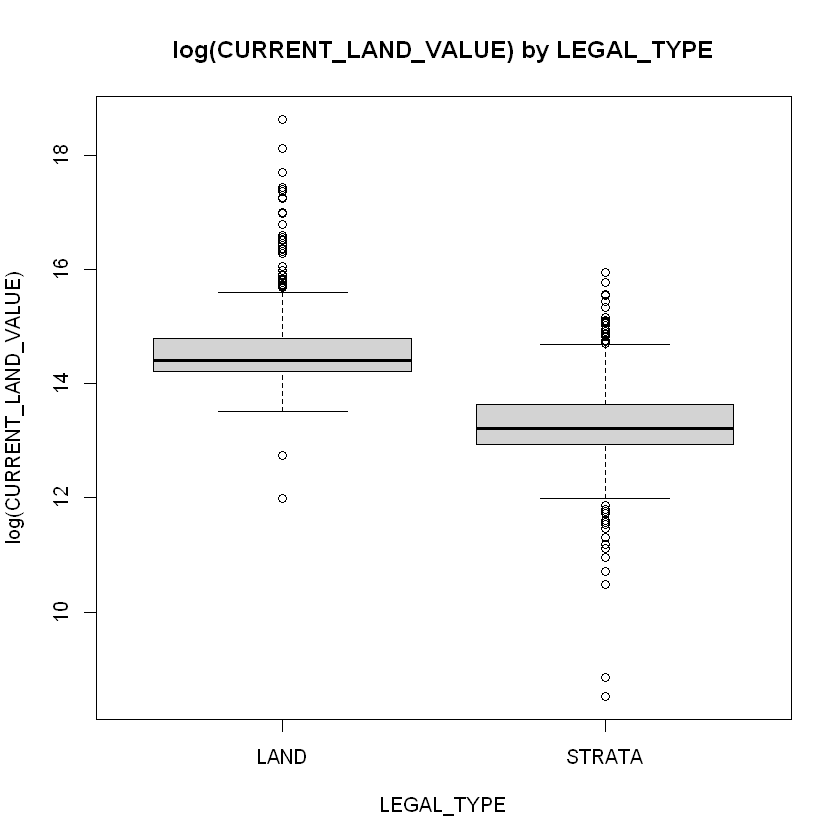

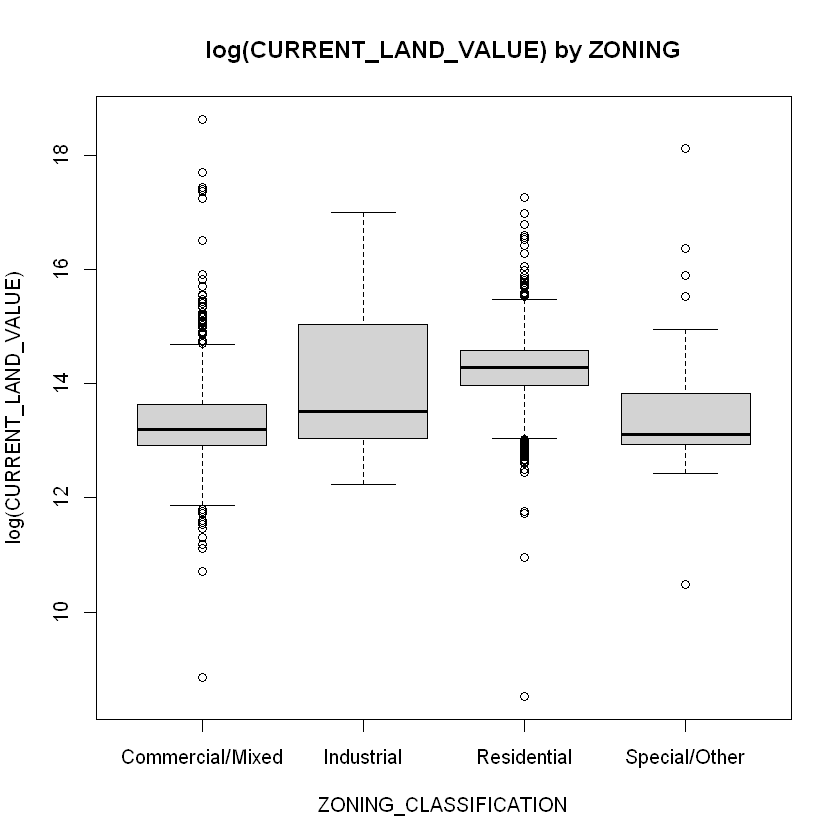

In [100]:
 par(mfrow = c(1, 1), mar = c(5,4,4,2))

boxplot(log(CURRENT_LAND_VALUE) ~ LEGAL_TYPE,
        data = property_cleaned,
        main = "log(CURRENT_LAND_VALUE) by LEGAL_TYPE",
        xlab = "LEGAL_TYPE",
        ylab = "log(CURRENT_LAND_VALUE)",
        col = "lightgray")

boxplot(log(CURRENT_LAND_VALUE) ~ ZONING_CLASSIFICATION,
        data = property_cleaned,
        main = "log(CURRENT_LAND_VALUE) by ZONING",
        xlab = "ZONING_CLASSIFICATION",
        ylab = "log(CURRENT_LAND_VALUE)",
        col = "lightgray")

par(mfrow = c(1, 1))

In [101]:
numeric_data <- data.frame(
  log_CURRENT_LAND_VALUE = log(property_cleaned$CURRENT_LAND_VALUE),
  log_PREVIOUS_LAND_VALUE = log(property_cleaned$PREVIOUS_LAND_VALUE),
  log_PREVIOUS_IMPROVEMENT_VALUE = log(property_cleaned$PREVIOUS_IMPROVEMENT_VALUE),
  YEAR_BUILT = property_cleaned$YEAR_BUILT
)

round(cor(numeric_data), 3)

,log_CURRENT_LAND_VALUE,log_PREVIOUS_LAND_VALUE,log_PREVIOUS_IMPROVEMENT_VALUE,YEAR_BUILT
log_CURRENT_LAND_VALUE,1.000,0.994,0.232,-0.398
log_PREVIOUS_LAND_VALUE,0.994,1.000,0.239,-0.387
log_PREVIOUS_IMPROVEMENT_VALUE,0.232,0.239,1.000,0.394
YEAR_BUILT,-0.398,-0.387,0.394,1.000


--------------------------
#### Model Selection

In [102]:
# Define null and full model
fit_null <- lm(log(CURRENT_LAND_VALUE) ~ 1, data = property_cleaned)

fit_full <- lm(
                log(CURRENT_LAND_VALUE) ~ 
                    log(PREVIOUS_LAND_VALUE) +
                    log(PREVIOUS_IMPROVEMENT_VALUE) +
                    YEAR_BUILT +
                    LEGAL_TYPE +
                    ZONING_CLASSIFICATION,
                data = property_cleaned
                )

# Full stepwise (both directions)
fit_step <- step(fit_null, 
                 direction = "both", 
                 scope = formula(fit_full))

# Start from full model, remove predictors one by one
fit_backward <- step(fit_full, direction = "backward")

# Start from null, add predictors one by one
fit_forward <- step(fit_null, direction = "forward", scope = formula(fit_full))

# Summary of chosen model
cat("Stepwise Selection (both directions):")
summary(fit_step)
AIC(fit_step)

cat("Backward Selection:")
summary(fit_backward)
AIC(fit_backward)

cat("Forward Selection:")
summary(fit_forward)
AIC(fit_forward)

Start:  AIC=-464.08
log(CURRENT_LAND_VALUE) ~ 1

                                  Df Sum of Sq     RSS     AIC
+ log(PREVIOUS_LAND_VALUE)         1   1463.38   18.43 -8775.5
+ LEGAL_TYPE                       1    734.40  747.41 -1759.0
+ ZONING_CLASSIFICATION            3    356.64 1125.17  -979.8
+ YEAR_BUILT                       1    234.98 1246.83  -789.3
+ log(PREVIOUS_IMPROVEMENT_VALUE)  1     80.09 1401.72  -567.4
<none>                                         1481.81  -464.1

Step:  AIC=-8775.47
log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE)

                                  Df Sum of Sq     RSS     AIC
+ ZONING_CLASSIFICATION            3      0.66   17.77 -8838.2
+ LEGAL_TYPE                       1      0.49   17.94 -8825.1
+ YEAR_BUILT                       1      0.34   18.09 -8809.0
+ log(PREVIOUS_IMPROVEMENT_VALUE)  1      0.03   18.40 -8777.0
<none>                                           18.43 -8775.5
- log(PREVIOUS_LAND_VALUE)         1   1463.38 1481.81  -46


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    ZONING_CLASSIFICATION + LEGAL_TYPE + YEAR_BUILT + log(PREVIOUS_IMPROVEMENT_VALUE), 
    data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59026 -0.05298  0.00781  0.05728  0.62298 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         0.999081   0.209584   4.767 2.01e-06 ***
log(PREVIOUS_LAND_VALUE)            0.967633   0.003941 245.537  < 2e-16 ***
ZONING_CLASSIFICATIONIndustrial     0.024522   0.013707   1.789  0.07377 .  
ZONING_CLASSIFICATIONResidential    0.029951   0.006450   4.644 3.66e-06 ***
ZONING_CLASSIFICATIONSpecial/Other -0.003791   0.015666  -0.242  0.80880    
LEGAL_TYPESTRATA                   -0.021502   0.008131  -2.645  0.00825 ** 
YEAR_BUILT                         -0.000318   0.000104  -3.057  0.00227 ** 
log(PREVIOUS_IMPROVEMENT_VALUE)     0.006906   0.002492   2.771  0.00564 *

[1] -3473.593

Backward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + LEGAL_TYPE + 
    ZONING_CLASSIFICATION, data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59026 -0.05298  0.00781  0.05728  0.62298 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         0.999081   0.209584   4.767 2.01e-06 ***
log(PREVIOUS_LAND_VALUE)            0.967633   0.003941 245.537  < 2e-16 ***
log(PREVIOUS_IMPROVEMENT_VALUE)     0.006906   0.002492   2.771  0.00564 ** 
YEAR_BUILT                         -0.000318   0.000104  -3.057  0.00227 ** 
LEGAL_TYPESTRATA                   -0.021502   0.008131  -2.645  0.00825 ** 
ZONING_CLASSIFICATIONIndustrial     0.024522   0.013707   1.789  0.07377 .  
ZONING_CLASSIFICATIONResidential    0.029951   0.006450   4.644 3.66e-06 ***
ZONING_CLASSIFICATIONSpecial/Other -0.003791   0.015666  -0.242  0.80880  

[1] -3473.593

Forward Selection:


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) + 
    ZONING_CLASSIFICATION + LEGAL_TYPE + YEAR_BUILT + log(PREVIOUS_IMPROVEMENT_VALUE), 
    data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.59026 -0.05298  0.00781  0.05728  0.62298 

Coefficients:
                                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)                         0.999081   0.209584   4.767 2.01e-06 ***
log(PREVIOUS_LAND_VALUE)            0.967633   0.003941 245.537  < 2e-16 ***
ZONING_CLASSIFICATIONIndustrial     0.024522   0.013707   1.789  0.07377 .  
ZONING_CLASSIFICATIONResidential    0.029951   0.006450   4.644 3.66e-06 ***
ZONING_CLASSIFICATIONSpecial/Other -0.003791   0.015666  -0.242  0.80880    
LEGAL_TYPESTRATA                   -0.021502   0.008131  -2.645  0.00825 ** 
YEAR_BUILT                         -0.000318   0.000104  -3.057  0.00227 ** 
log(PREVIOUS_IMPROVEMENT_VALUE)     0.006906   0.002492   2.771  0.00564 *

[1] -3473.593

--------------------------
#### Fitting Models

In [103]:
fit_add <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    LEGAL_TYPE +
    ZONING_CLASSIFICATION,
  data = property_cleaned
)

fit_int_zone <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) * ZONING_CLASSIFICATION +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    LEGAL_TYPE,
  data = property_cleaned
)

fit_int_legal <- lm(
  log(CURRENT_LAND_VALUE) ~
    log(PREVIOUS_LAND_VALUE) * LEGAL_TYPE +
    log(PREVIOUS_IMPROVEMENT_VALUE) +
    YEAR_BUILT +
    ZONING_CLASSIFICATION,
  data = property_cleaned
)
anova_zone <- anova(fit_add, fit_int_zone)
anova_legal <- anova(fit_add, fit_int_legal)

anova_legal

data.frame(
  Model = c("Additive", "Zone interaction", "Legal interaction"),
  AIC = c(AIC(fit_add), AIC(fit_int_zone), AIC(fit_int_legal)),
  Adj_R2 = c(
    summary(fit_add)$adj.r.squared,
    summary(fit_int_zone)$adj.r.squared,
    summary(fit_int_legal)$adj.r.squared
  ),
  Residual_SE = c(
    summary(fit_add)$sigma,
    summary(fit_int_zone)$sigma,
    summary(fit_int_legal)$sigma
  ),
   F_value = c(
    NA,
    anova_zone$F[2],
    anova_legal$F[2]
  ),
  P_value = c(
    NA,
    anova_zone$`Pr(>F)`[2],
    anova_legal$`Pr(>F)`[2]
  )
)

,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1887,17.57659,NA,NA,NA,NA
2,1886,17.49701,1,0.07957558,8.577439,0.003444372


Model,AIC,Adj_R2,Residual_SE,F_value,P_value
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Additive,-3473.593,0.9880944,0.09651200,NA,NA
Zone interaction,-3476.040,0.9881285,0.09637379,2.805441,0.038432652
Legal interaction,-3480.192,0.9881421,0.09631881,8.577439,0.003444372


In [104]:
summary(fit_int_legal)


Call:
lm(formula = log(CURRENT_LAND_VALUE) ~ log(PREVIOUS_LAND_VALUE) * 
    LEGAL_TYPE + log(PREVIOUS_IMPROVEMENT_VALUE) + YEAR_BUILT + 
    ZONING_CLASSIFICATION, data = property_cleaned)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.58695 -0.05138  0.00692  0.05720  0.61447 

Coefficients:
                                            Estimate Std. Error t value
(Intercept)                                1.2334892  0.2239544   5.508
log(PREVIOUS_LAND_VALUE)                   0.9538346  0.0061372 155.417
LEGAL_TYPESTRATA                          -0.3272524  0.1047120  -3.125
log(PREVIOUS_IMPROVEMENT_VALUE)            0.0073101  0.0024909   2.935
YEAR_BUILT                                -0.0003359  0.0001040  -3.230
ZONING_CLASSIFICATIONIndustrial            0.0276705  0.0137213   2.017
ZONING_CLASSIFICATIONResidential           0.0263812  0.0065511   4.027
ZONING_CLASSIFICATIONSpecial/Other        -0.0015340  0.0156538  -0.098
log(PREVIOUS_LAND_VALUE):LEGAL_TYPESTRATA 

--------------------------
#### Analysis Plots

In [105]:
vif_add <- vif(fit_add)
vif_add

,GVIF,Df,GVIF^(1/(2*Df))
log(PREVIOUS_LAND_VALUE),2.489310,1,1.577755
log(PREVIOUS_IMPROVEMENT_VALUE),1.571920,1,1.253762
YEAR_BUILT,1.962373,1,1.400847
LEGAL_TYPE,3.220498,1,1.794575
ZONING_CLASSIFICATION,2.080597,3,1.129877


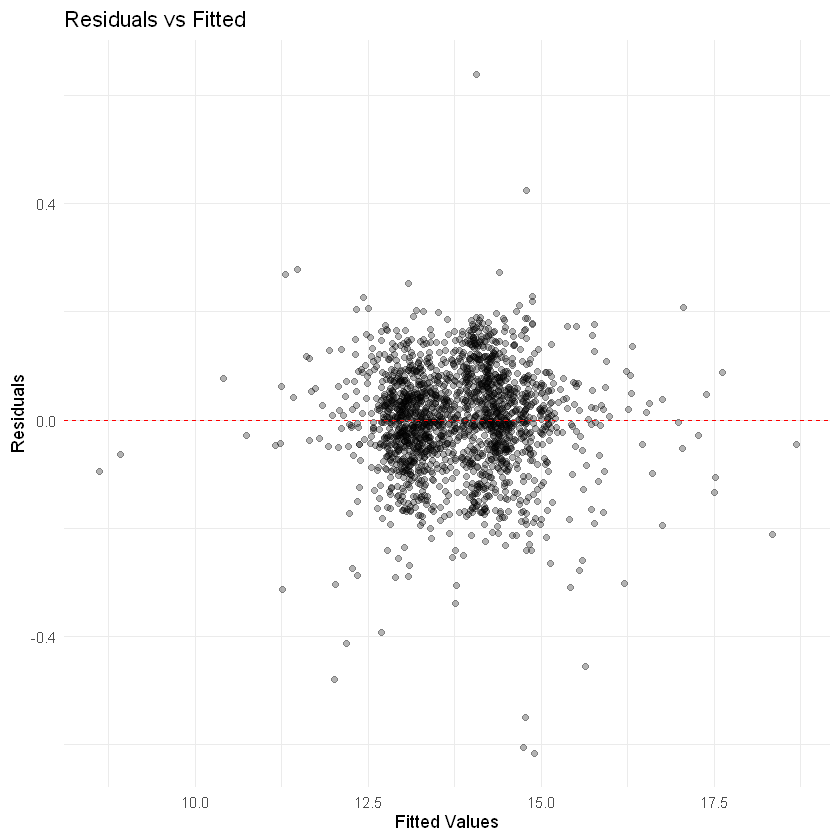

In [68]:
ggplot(data.frame(fitted = fit$fitted.values, residuals = fit$residuals),
       aes(x = fitted, y = residuals)) +
  geom_point(alpha = 0.3) +
  geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
  labs(x = "Fitted Values", y = "Residuals",
       title = "Residuals vs Fitted") +
  theme_minimal()

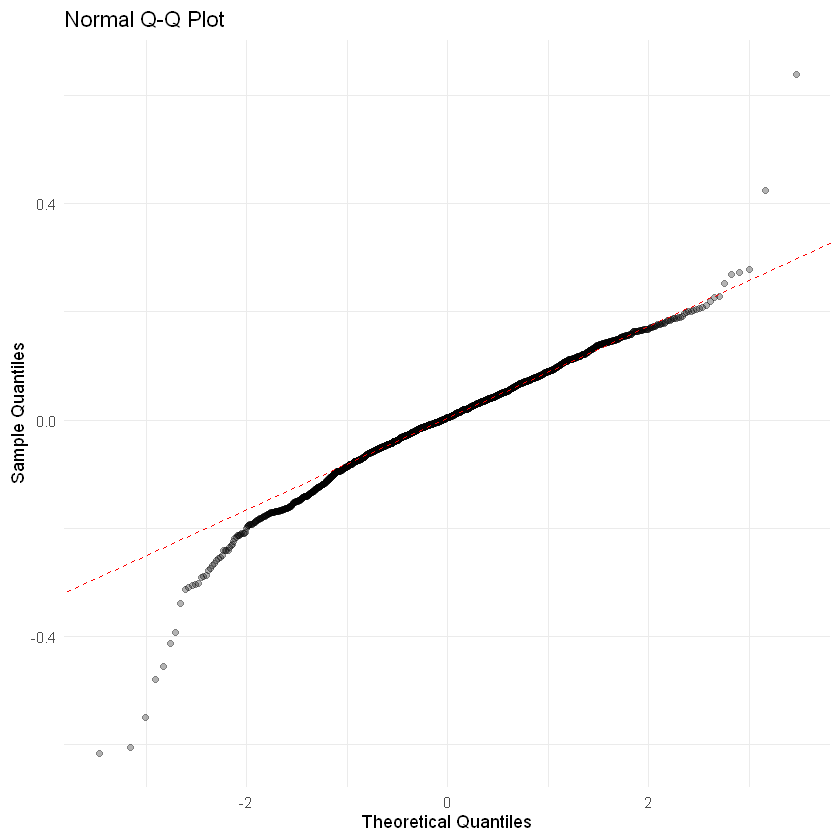

In [77]:
ggplot(data.frame(residuals = fit$residuals), aes(sample = residuals)) +
  stat_qq(alpha = 0.3) +
  stat_qq_line(color = "red", linetype = "dashed") +
  labs(x = "Theoretical Quantiles", y = "Sample Quantiles",
       title = "Normal Q-Q Plot") +
  theme_minimal()